# 📊 Sub-Task.정형+비정형 Hybrid 분석 Tutorial 

__Tutorial 목적__

실제 산업에서는 생산데이터와 같이 계속적으로 취득되는 정형 데이터들이 많지만, 해당 데이터들의 컬럼간 인과관계에 대한 분석이 어렵고(공정간 인과관계 등), 배경 지식과 AI를 결합한 Domain-adapted AI를 개발하는것은 비개발자에게는 벽이 높다. 따라서 실제로 쌓이는 데이터의 양은 많지만 정형 데이터로부터 뽑아내는 인사이트는 한정적이다. 

또한, AI를 어찌저찌 개발해서 결과를 뽑아낸다고 해도, 항상 받는 질문이 있다. 

```"AI는 블랙박스가 아닌가? AI를 어떻게 믿어?"```

AI를 개발하는 시간보다, AI가 도출한 결론에 대한 근거와 해석을 찾는 데 오히려 더 많은 시간을 쏟게 되고, AI의 결론 중 수많은 유의미한 결과들이 사람을 설득하지 못해서 사라진다. 

본 튜토리얼은 AI가 사람처럼 정형 데이터를 처리하고, 연산하고, 결과를 해석하여 사람에게 설명을 제공한다. 

진정한 의미의 __"설명 가능한 인공지능"__ 의 등장이다. 


## 💡 목차
> (1) 사용 데이터셋 설명
> 
> (2) Exploaroty Data Analysis (EDA)
>
> (3) Machine Learning (ML)
>
> (4) Quick EDA & ML Report 생성
>
> (5) LLM 기반 정형 데이터 분석 Report 생성
>
> (6) RAG 기반 Report 가이드 추가
>
> (7) 정형+비정형 Hybrid 분석 최종 Report 생성
>
> (8) RAG 기반 ML성능개선 ```(optional)```
>


## (1) 사용 데이터셋 설명

**AI4I 2020 Predictive Maintenance Dataset**

```AI4I Predictive Maintenance Dataset```은 산업 장비의 고장을 분석하고 예측하기 위해 생성된 장비 운전 데이터이다. (simulation data)

각 행(row)은 장비가 특정 시점에 작동하고 있을 때의 상태 정보를 의미하며,
각 컬럼(column)은 장비의 온도, 회전 속도, 토크, 마모 정도 등 장비 상태를 나타내는 센서 데이터와 고장 여부 정보로 구성되어 있다.

즉,
장비 운전 상태 데이터 + 실제 고장 발생 여부가 함께 들어 있는 데이터로
이를 통해 어떤 상태에서 장비 고장이 발생하는지 분석하거나 고장을 미리 예측하는 모델을 만드는 데 사용된다.

---


In [1]:
from utils.api import *

In [2]:
# !pip install google-genai

from google import genai

def invoke_llm(contents):
    API_KEY = gemini_api_key  ## gemini api key 발급받아서 넣기 
    client = genai.Client(api_key=API_KEY)
    response = client.models.generate_content(
        model="gemini-2.5-flash-lite",
        contents=contents
    )
    return response.text
    

## (2) Exploaroty Data Analysis (EDA)

In [3]:
############################################################
# 1. 라이브러리 불러오기
############################################################

# pandas : 데이터 테이블 처리
import pandas as pd

# numpy : 수치 계산
import numpy as np

# matplotlib : 기본 그래프
import matplotlib.pyplot as plt

# seaborn : 통계 시각화
import seaborn as sns

# 그래프 스타일 설정
sns.set(style="whitegrid")

print("라이브러리 로드 완료")


라이브러리 로드 완료


In [4]:
############################################################
# 2. 데이터 불러오기
############################################################

# CSV 파일 읽기
data = pd.read_csv("./Data/Tabular/AI4I.csv")

# 데이터 일부 확인
print("데이터 샘플")
print(data.head())

데이터 샘플
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


In [5]:
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [6]:
############################################################
# 3. 데이터 기본 구조 확인
############################################################

print("\n데이터 구조 확인")
data.info()

# 분석 목적
# - 데이터 개수 확인
# - 컬럼 타입 확인
# - 결측치 존재 여부 확인


데이터 구조 확인
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [7]:
############################################################
# 4. 컬럼 목록 확인
############################################################

print("\n컬럼 목록")
print(data.columns)

# 분석 목적
# 어떤 변수들이 존재하는지 이해하기


컬럼 목록
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='str')


In [8]:
############################################################
# 5. 데이터 크기 확인
############################################################

print("\n데이터 크기")
print(data.shape)

# 분석 목적
# 행(row)과 열(column)의 개수 확인


데이터 크기
(10000, 10)


In [9]:
############################################################
# 6. 결측치 확인
############################################################

print("\n결측치 확인")
print(data.isnull().sum())

# AI4I 데이터는 보통 결측치가 없음


결측치 확인
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [10]:
############################################################
# 7. 기본 통계 확인
############################################################

print("\n기본 통계")
print(data.describe())

# 분석 목적
# 센서 데이터 범위 이해
# 평균 / 최대 / 최소 값 확인


기본 통계
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]        Target  
count            10000.000000  10000.000000     10000.000000  10000.000000  
mean              1538.776100     39.986910       107.951000      0.033900  
std                179.284096      9.968934        63.654147      0.180981  
min               1168.000000      3.800000         0.000000      0.0000

In [11]:
############################################################
# 8. 범주형 변수 확인
############################################################

print("\nType 분포")
print(data["Type"].value_counts())

print("\nFailure Type 분포")
print(data["Failure Type"].value_counts())

# 분석 목적
# - 제품 타입 분포
# - 고장 유형 분포 확인


Type 분포
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Failure Type 분포
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


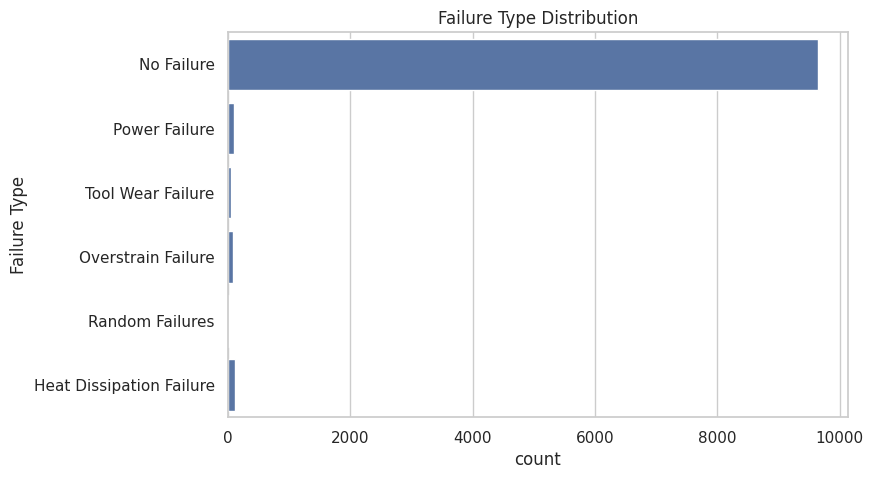

In [12]:
############################################################
# 9. Failure Type 시각화
############################################################

plt.figure(figsize=(8,5))

sns.countplot(y="Failure Type", data=data)

plt.title("Failure Type Distribution")

plt.show()

# 인사이트
# 대부분 데이터는 No Failure

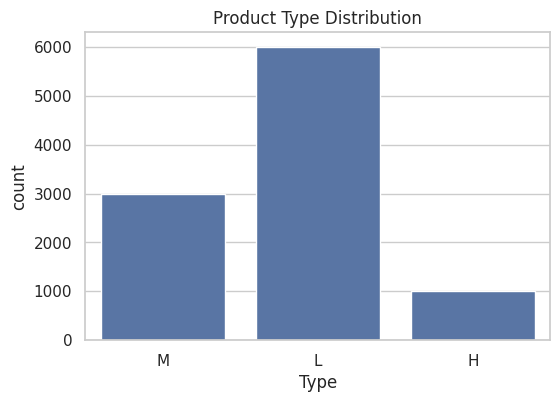

In [13]:
############################################################
# 10. Product Type 시각화
############################################################

plt.figure(figsize=(6,4))

sns.countplot(x="Type", data=data)

plt.title("Product Type Distribution")

plt.show()

# 인사이트
# 제품 타입 분포 확인

In [14]:
############################################################
# 11. 주요 센서 변수 정의
############################################################

sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print("\n센서 컬럼")
print(sensor_columns)


센서 컬럼
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


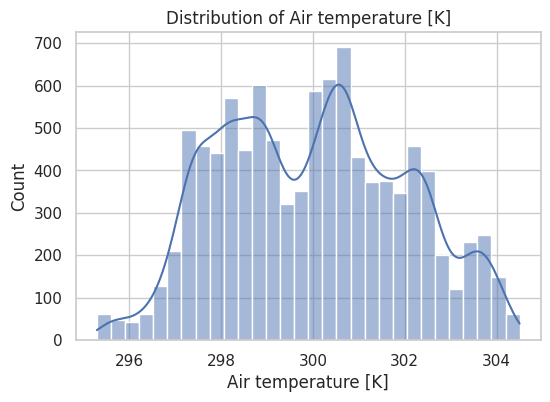

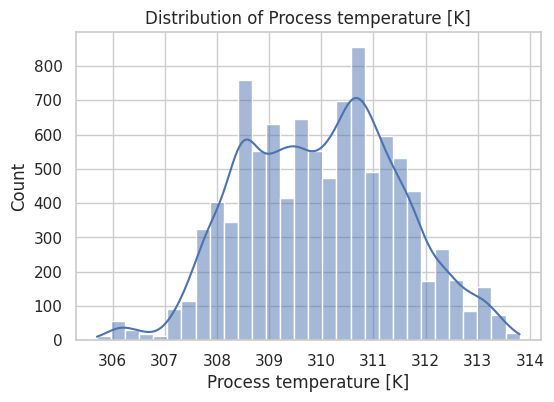

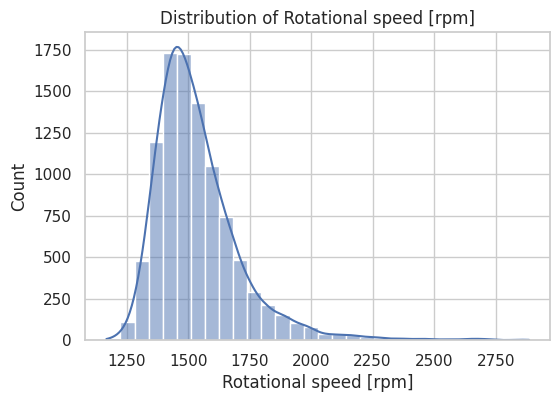

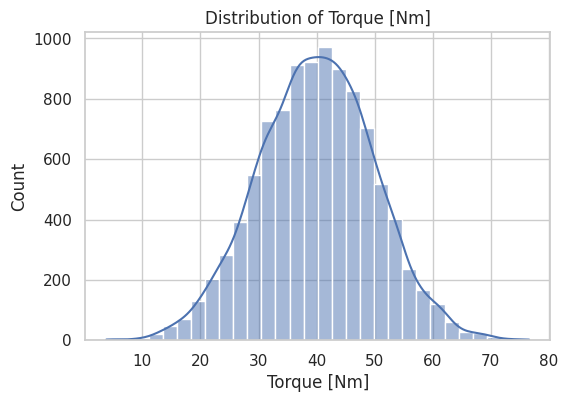

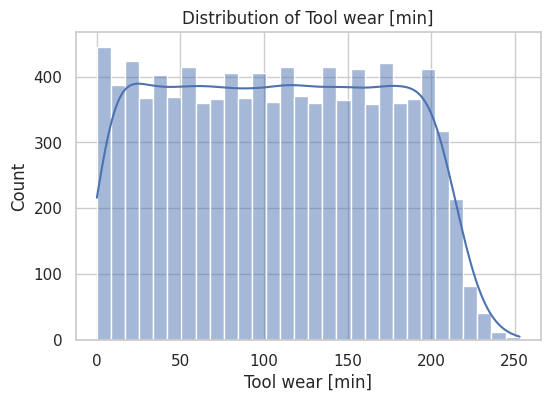

In [15]:
############################################################
# 12. 센서 데이터 히스토그램
############################################################

for col in sensor_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(data[col], bins=30, kde=True)

    plt.title("Distribution of " + col)

    plt.show()

# 분석 목적
# 데이터 분포 확인
# 이상값 탐색

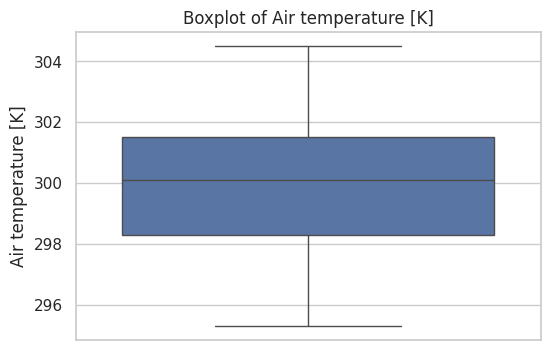

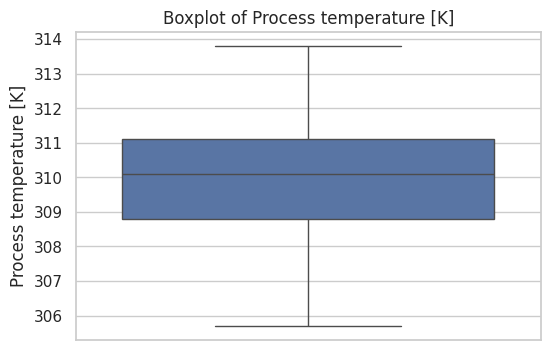

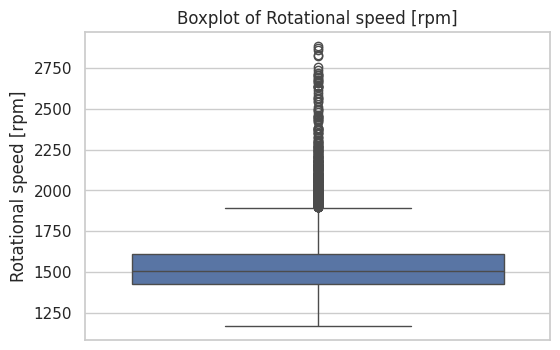

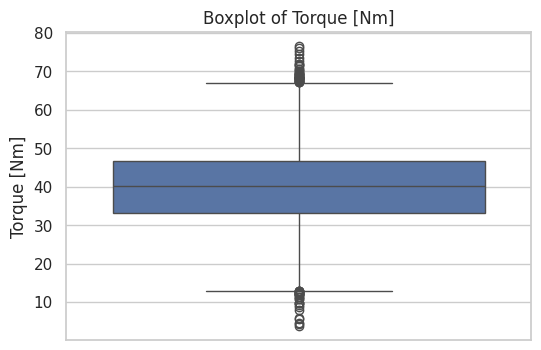

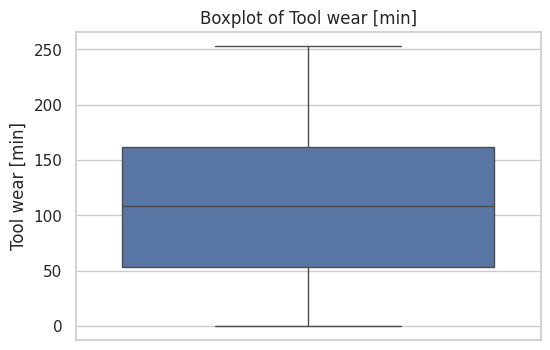

In [16]:
############################################################
# 13. 센서 데이터 박스플롯
############################################################

for col in sensor_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(y=data[col])

    plt.title("Boxplot of " + col)

    plt.show()

# 분석 목적
# 이상치(outlier) 탐색

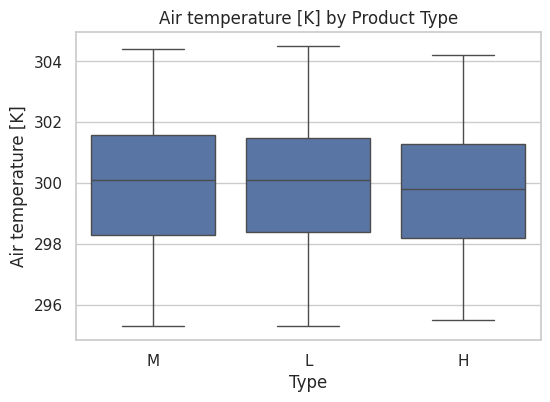

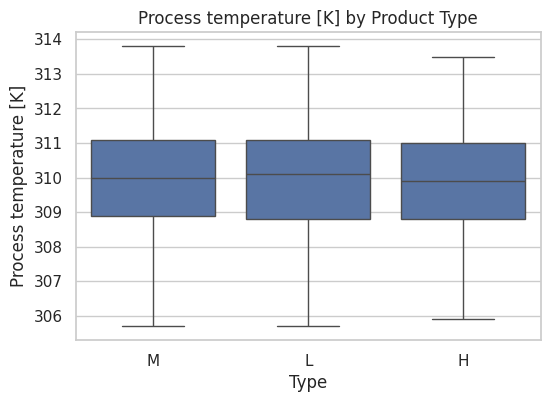

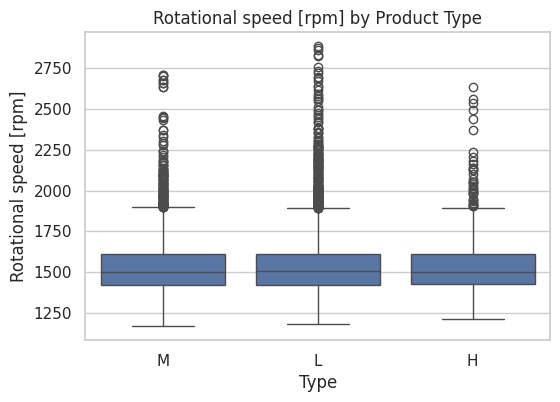

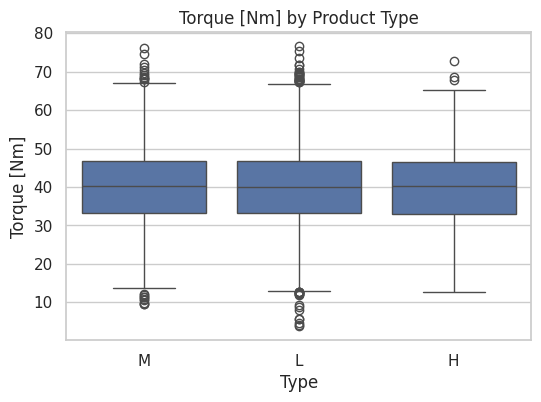

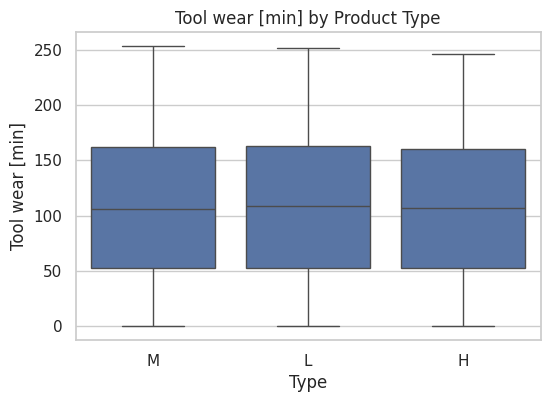

In [17]:
############################################################
# 14. Product Type별 센서 비교
############################################################

for col in sensor_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x="Type", y=col, data=data)

    plt.title(col + " by Product Type")

    plt.show()

# 분석 목적
# 제품 타입별 센서 차이 확인

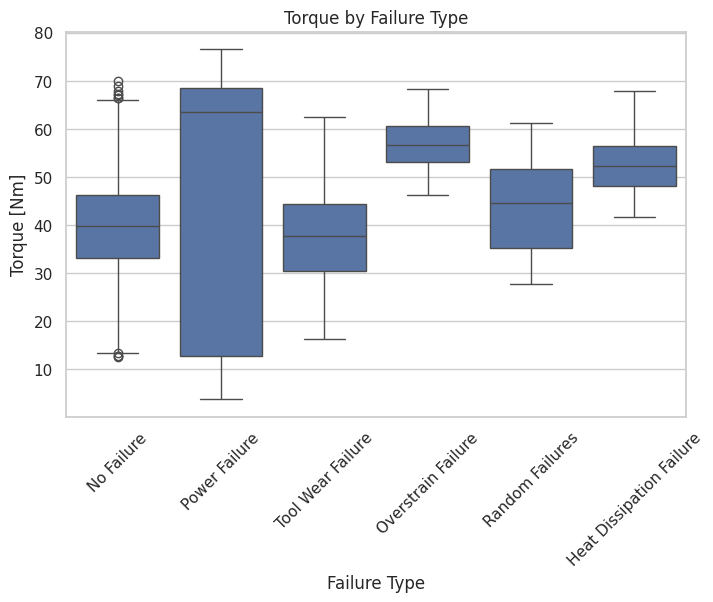

In [18]:
############################################################
# 15. Failure Type별 Torque 분석
############################################################

plt.figure(figsize=(8,5))

sns.boxplot(x="Failure Type", y="Torque [Nm]", data=data)

plt.xticks(rotation=45)

plt.title("Torque by Failure Type")

plt.show()

# 분석 목적
# 특정 고장에서 torque가 높아지는지 확인

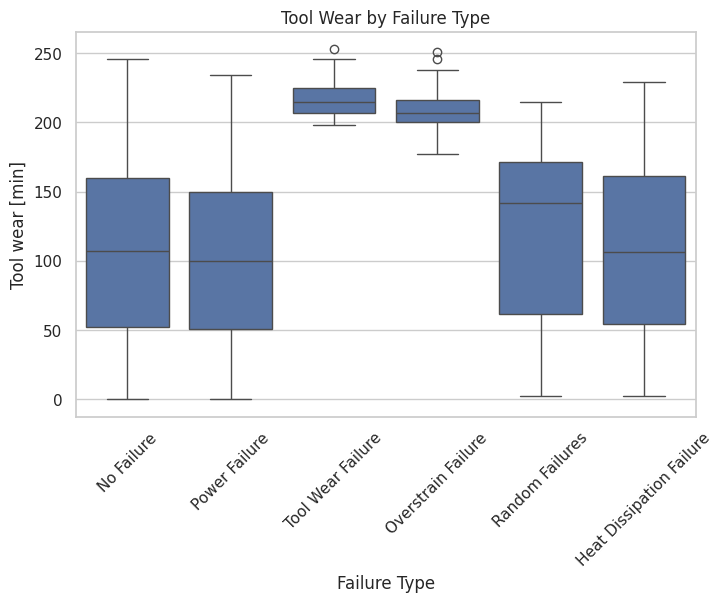

In [19]:
############################################################
# 16. Failure Type별 Tool Wear 분석
############################################################

plt.figure(figsize=(8,5))

sns.boxplot(x="Failure Type", y="Tool wear [min]", data=data)

plt.xticks(rotation=45)

plt.title("Tool Wear by Failure Type")

plt.show()

# 분석 목적
# Tool Wear Failure 확인

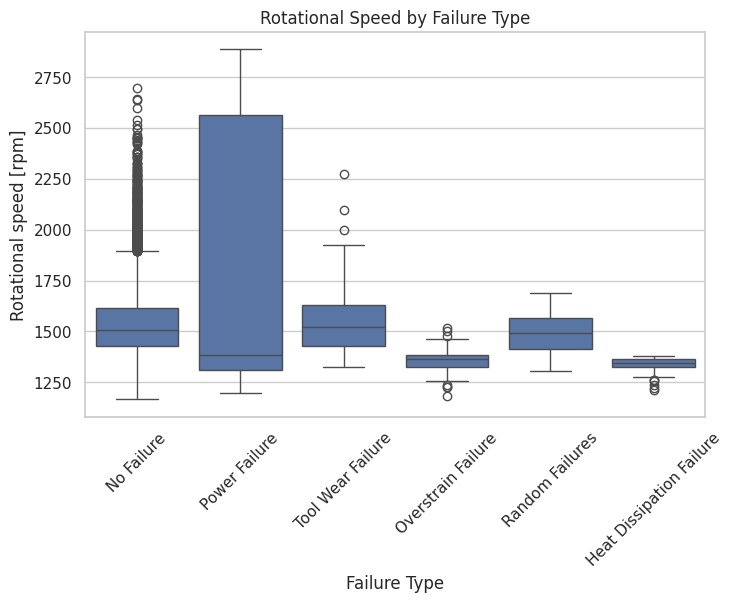

In [20]:
############################################################
# 17. Failure Type별 Rotational Speed 분석
############################################################

plt.figure(figsize=(8,5))

sns.boxplot(x="Failure Type", y="Rotational speed [rpm]", data=data)

plt.xticks(rotation=45)

plt.title("Rotational Speed by Failure Type")

plt.show()

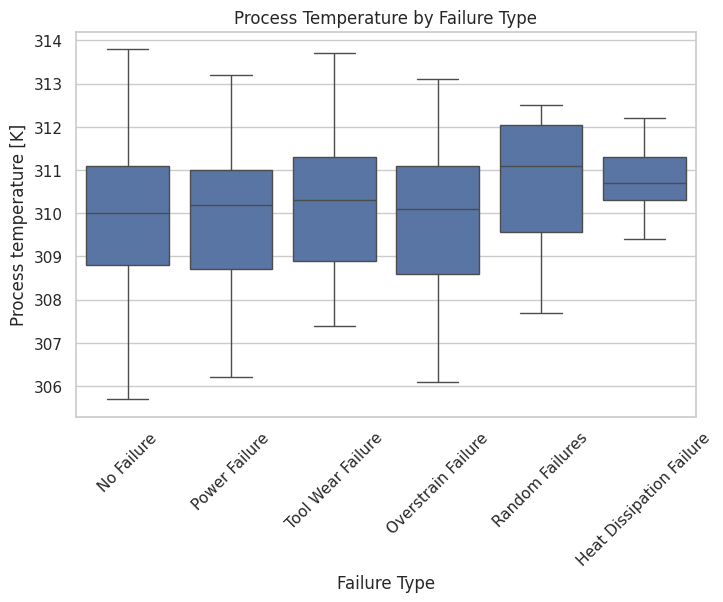

In [21]:
############################################################
# 18. Failure Type별 Temperature 분석
############################################################

plt.figure(figsize=(8,5))

sns.boxplot(x="Failure Type", y="Process temperature [K]", data=data)

plt.xticks(rotation=45)

plt.title("Process Temperature by Failure Type")

plt.show()

In [22]:
############################################################
# 19. 상관관계 분석 준비
############################################################

numeric_data = data.select_dtypes(include=["int64","float64"])

In [23]:
############################################################
# 20. 상관관계 계산
############################################################

corr = numeric_data.corr()

print("\n상관관계 행렬")
print(corr)


상관관계 행렬
                              UDI  Air temperature [K]  \
UDI                      1.000000             0.117428   
Air temperature [K]      0.117428             1.000000   
Process temperature [K]  0.324428             0.876107   
Rotational speed [rpm]  -0.006615             0.022670   
Torque [Nm]              0.003207            -0.013778   
Tool wear [min]         -0.010702             0.013853   
Target                  -0.022892             0.082556   

                         Process temperature [K]  Rotational speed [rpm]  \
UDI                                     0.324428               -0.006615   
Air temperature [K]                     0.876107                0.022670   
Process temperature [K]                 1.000000                0.019277   
Rotational speed [rpm]                  0.019277                1.000000   
Torque [Nm]                            -0.014061               -0.875027   
Tool wear [min]                         0.013488                0.0002

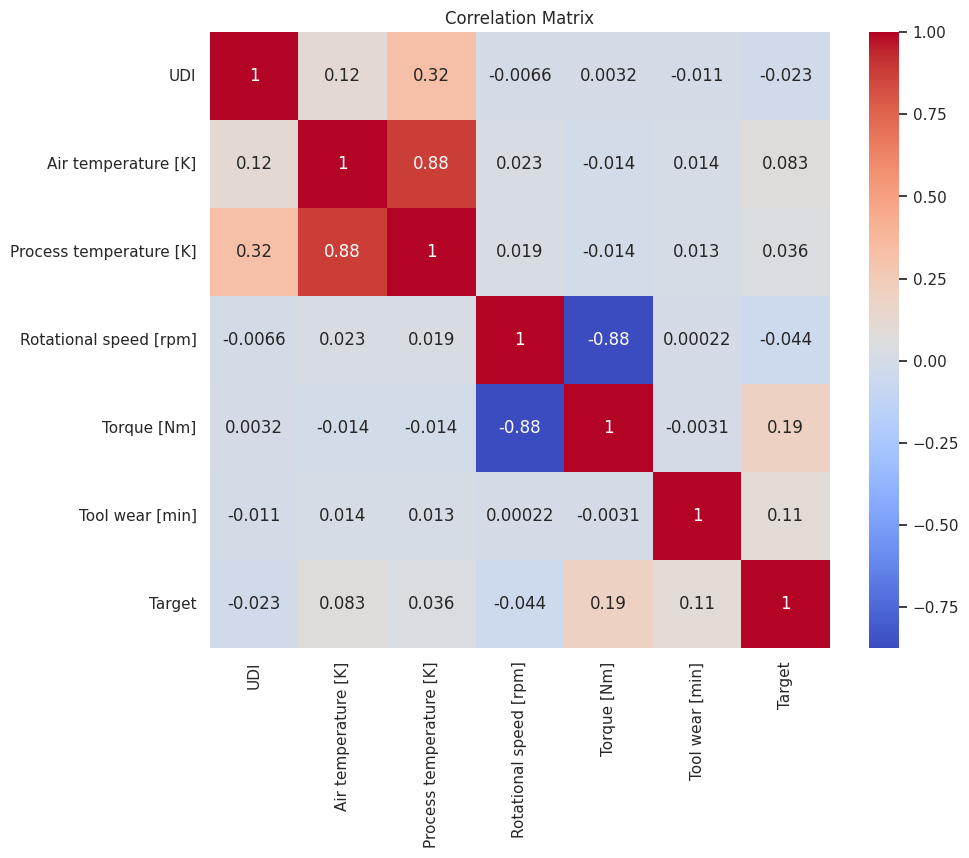

In [24]:
############################################################
# 21. 상관관계 히트맵
############################################################

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# 분석 목적
# 센서 간 관계 파악

In [25]:
############################################################
# 22. Failure Type별 평균 센서값
############################################################

failure_means = data.groupby("Failure Type")[sensor_columns].mean()

print("\nFailure Type별 평균 센서값")
print(failure_means)


Failure Type별 평균 센서값
                          Air temperature [K]  Process temperature [K]  \
Failure Type                                                             
Heat Dissipation Failure           302.567857               310.799107   
No Failure                         299.972855               309.994343   
Overstrain Failure                 299.867949               310.051282   
Power Failure                      300.075789               309.954737   
Random Failures                    300.766667               310.755556   
Tool Wear Failure                  300.288889               310.164444   

                          Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Failure Type                                                                    
Heat Dissipation Failure             1337.964286    52.778571       107.339286  
No Failure                           1540.324389    39.624316       106.678927  
Overstrain Failure                   1354.243590    56.878205

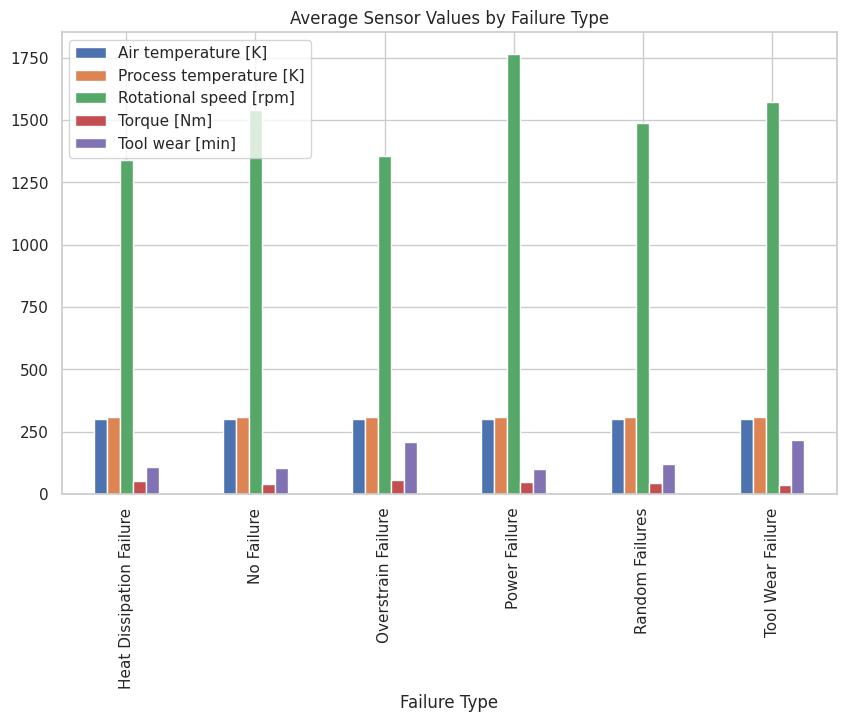

In [26]:
############################################################
# 23. Failure Type 평균 그래프
############################################################

failure_means.plot(kind="bar", figsize=(10,6))

plt.title("Average Sensor Values by Failure Type")

plt.show()

# 분석 목적
# 고장 유형별 특징 파악

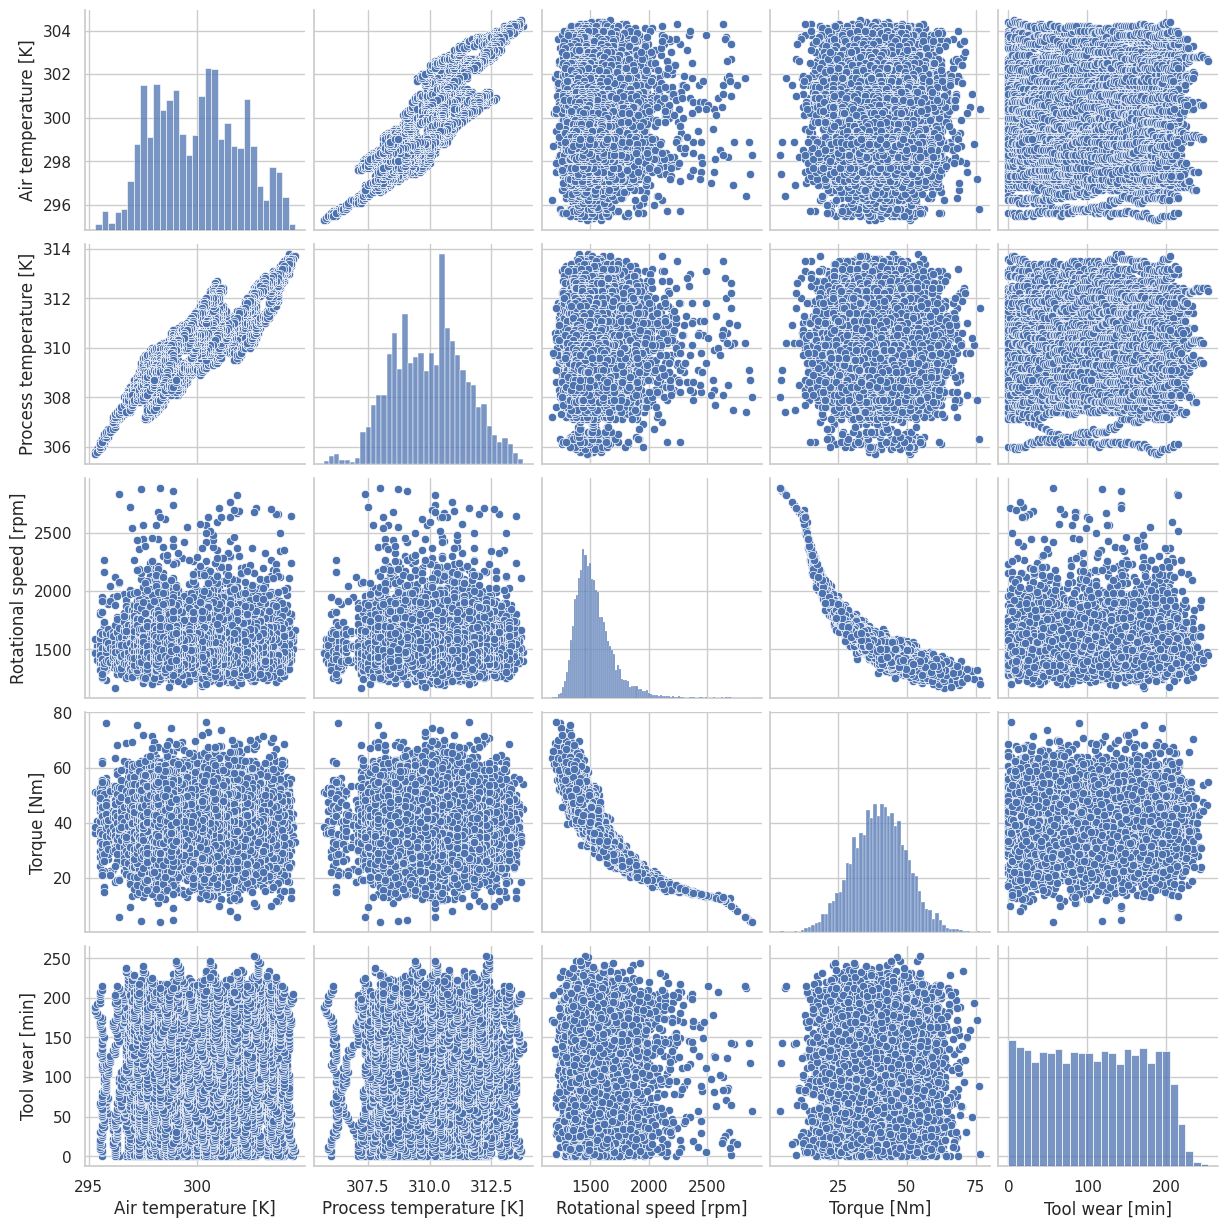

In [27]:
############################################################
# 24. Pairplot 분석
############################################################

sns.pairplot(data[sensor_columns])

plt.show()

# 분석 목적
# 변수 관계 탐색

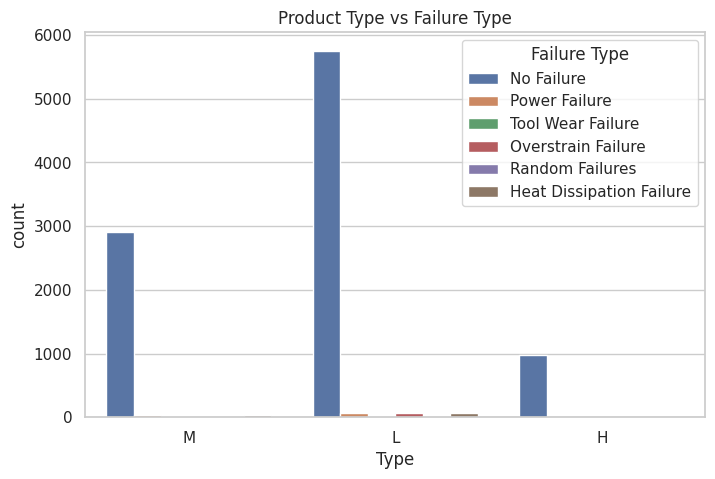

In [28]:
############################################################
# 25. Product Type vs Failure
############################################################

plt.figure(figsize=(8,5))

sns.countplot(x="Type", hue="Failure Type", data=data)

plt.title("Product Type vs Failure Type")

plt.show()

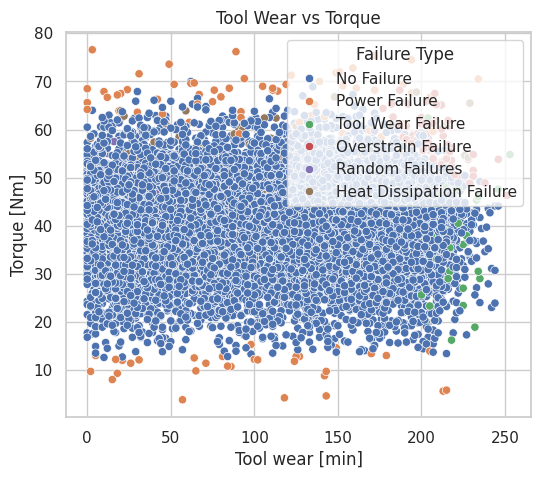

In [29]:
############################################################
# 26. Tool Wear vs Torque Scatter
############################################################

plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Tool wear [min]",
    y="Torque [Nm]",
    hue="Failure Type",
    data=data
)

plt.title("Tool Wear vs Torque")

plt.show()

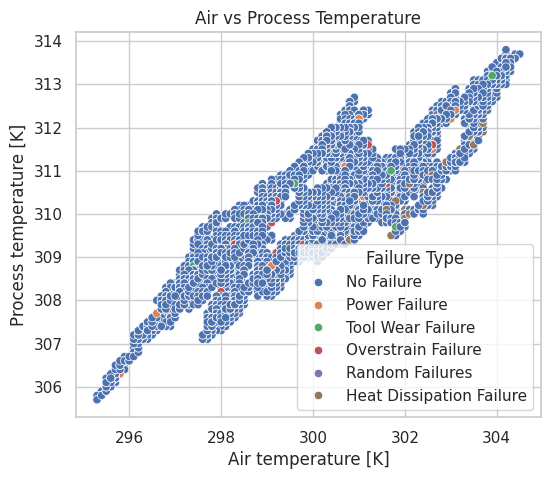

In [30]:
############################################################
# 27. Temperature 관계 분석
############################################################

plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Failure Type",
    data=data
)

plt.title("Air vs Process Temperature")

plt.show()

In [31]:
############################################################
# 28. Failure Type 숫자 변환
############################################################

data["Failure_Code"] = data["Failure Type"].astype("category").cat.codes

print(data[["Failure Type","Failure_Code"]].head())

  Failure Type  Failure_Code
0   No Failure             1
1   No Failure             1
2   No Failure             1
3   No Failure             1
4   No Failure             1


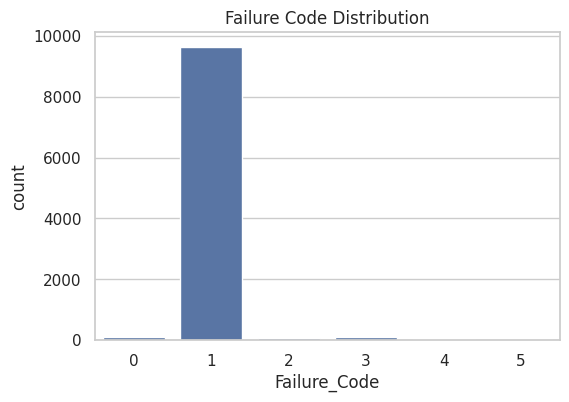

In [32]:
############################################################
# 29. Failure Code 분포
############################################################

plt.figure(figsize=(6,4))

sns.countplot(x="Failure_Code", data=data)

plt.title("Failure Code Distribution")

plt.show()

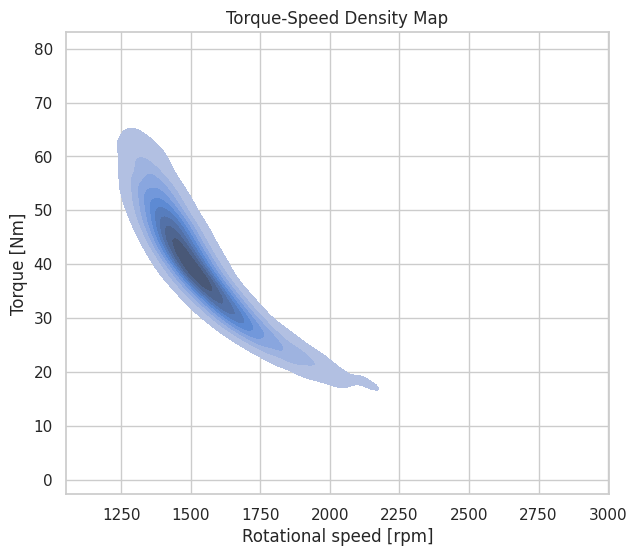

In [33]:
## AI4I 데이터셋 유명한 EDA 

plt.figure(figsize=(7,6))

sns.kdeplot(
    data=data,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    fill=True
)

plt.title("Torque-Speed Density Map")

plt.show()

In [34]:
## EDA 레포트 생성
from utils.Generate_EDA_Report import *



AI4I Predictive Maintenance Dataset - EDA Summary

[1] Dataset Overview

Number of rows : 10000
Number of columns : 10


[2] Missing Values

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


[3] Failure Distribution

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


[4] Product Type Distribution

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


[5] Sensor Statistics

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count         10000.000000             10000.000000            10000.000000   
mean        

## (3) Machine Learning (ML)

In [36]:
print(report_text)



AI4I Predictive Maintenance Dataset - EDA Summary

[1] Dataset Overview

Number of rows : 10000
Number of columns : 10


[2] Missing Values

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


[3] Failure Distribution

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


[4] Product Type Distribution

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


[5] Sensor Statistics

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count         10000.000000             10000.000000            10000.000000   
mean        

In [37]:
contents = f"""
아래 내용 해석해서 분류용 머신러닝 알고리즘 짜줘. 코드만 반환.
모든 코드는 함수명 "machine_learning" 으로 작성하고, 함수에 필수 입력값은 df로 고정해줘. 
입력 데이터는 "df" 변수로 할당하고, 직접 불러오는 코드는 작성하지 마. 
accuray와 classification report는 각각 변수명 "acc" "clf_report" 로 할당. 
사용한 알고리즘에 대한 설명과 해당 알고리즘을 선택한 이유도 text로 "algorithm_summary" 변수로 할당. 
백틱(`)이나 python 등 절대 출력하지마. 
[EDA 결과] {report_text}"""

In [ ]:
python_code = invoke_llm(contents)

if python_code.startswith('```python'): python_code = python_code[9:]
if python_code.endswith('```'): python_code = python_code[:-3]

print(python_code)

with open('AI4I_clf_model.py', 'w', encoding='utf-8') as file:
    file.write(python_code)

df = data.copy()

from AI4I_clf_model import machine_learning

acc, clf_report, algorithm_summary = machine_learning(df)

In [41]:
acc

0.996

In [43]:
print(clf_report)

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.96      1.00      0.98        22
              No Failure       1.00      1.00      1.00      1930
      Overstrain Failure       0.84      1.00      0.91        16
           Power Failure       1.00      0.89      0.94        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       1.00      0.78      0.88         9

                accuracy                           1.00      2000
               macro avg       0.80      0.78      0.79      2000
            weighted avg       0.99      1.00      0.99      2000



In [40]:
algorithm_summary

"\nRandomForestClassifier를 선택한 이유는 다음과 같습니다.\n1. 불균형 데이터셋 처리: EDA 결과에서 'Failure Type'의 분포가 불균형합니다. RandomForestClassifier는 개별 결정 트리의 약점을 보완하고 앙상블을 통해 전반적인 성능을 향상시켜 불균형 데이터셋에서도 비교적 강건한 성능을 보입니다.\n2. 높은 예측 성능: 여러 트리의 예측을 종합하기 때문에 과적합될 위험이 적고, 다양한 특징(feature)들을 고려하여 복잡한 관계를 학습하는 데 효과적입니다.\n3. 유연성: 범주형 및 수치형 데이터를 모두 처리할 수 있으며, 특성 중요도를 제공하여 모델 해석에 도움을 줍니다.\n    "

## (4) Quick EDA & ML Report 생성

In [41]:
integ_report = f"""{report_text}, 
                    ML 정확도: {acc}, 
                    Classification Report: {clf_report}
                    Algorithm Summary: {algorithm_summary}
                    """

print(integ_report)



AI4I Predictive Maintenance Dataset - EDA Summary

[1] Dataset Overview

Number of rows : 10000
Number of columns : 10


[2] Missing Values

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


[3] Failure Distribution

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


[4] Product Type Distribution

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


[5] Sensor Statistics

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count         10000.000000             10000.000000            10000.000000   
mean        

## (5) LLM 기반 정형 데이터 분석 Report 생성

In [42]:
from utils.prompt import *

In [43]:
contents = report_prompt + integ_report
report_html = invoke_llm(contents)

In [44]:
with open('AI4I_분석레포트.html', 'w', encoding='utf-8') as file:
    file.write(report_html)

## (6) RAG 기반 Report 가이드 추가

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9423.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [47]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_docs(query, docs=docs, top_k=2):
    
    query_emb = model.encode([query])    
    sim = cosine_similarity(query_emb, doc_embeddings)[0]
    idx = np.argsort(sim)[-top_k:]
    retrieved = [docs[i] for i in idx]
    
    return "\n".join(retrieved)

In [48]:
## RAG Test

query = "machine failure 원인과 센서 관계 설명"

rag_context = retrieve_docs(query)

print(rag_context)


Overstrain Failure:
Torque가 비정상적으로 높은 경우 발생한다.
기계 과부하 상황일 가능성이 높다.


Tool Wear Failure:
Tool wear 값이 높을 때 발생한다.
예방 정비로 tool 교체 필요.



## (7) 정형+비정형 Hybrid 분석 최종 Report 생성

In [49]:
contents_with_RAG = f"""

{report_prompt}
내용은 한국어로 작성하세요. 
다음은 설비 데이터 분석 결과입니다.

[EDA 결과]
{report_text}

[ML 결과]
Accuracy: {acc}

[Domain Knowledge]
{rag_context}

domain knowledge를 활용해서 인사이트를 도출하세요. 
도표는 도표로 생성할만한 값이 있을 때만 SVG로 생성하세요. 
위 정보를 기반으로 산업 설비 고장 분석 리포트를 작성하세요.
"""

In [50]:
final_report = invoke_llm(contents_with_RAG)

In [51]:
with open('AI4I_분석레포트_RAG.html', 'w', encoding='utf-8') as file:
    file.write(final_report)

In [82]:
from IPython.display import display, HTML

In [83]:
display(HTML(final_report))

## (8) RAG 기반 ML 성능 개선 ```(optional)```

In [52]:
from Data.RAG.RAG import ml_docs

In [53]:
ml_summary = f"""
Accuracy: {acc}
Classification Report: {clf_report}
Algorithm Summary: {algorithm_summary}
"""

In [54]:
ml_context = retrieve_docs(ml_summary, docs=ml_docs)

In [55]:
prompt = f"""
다음은 머신러닝 모델 결과입니다.
{ml_summary}

다음은 ML best practice 문서입니다.
{ml_context}

이 모델의 성능을 개선하기 위한 방법을 제안하세요.
다음을 포함하세요
1. Feature Engineering 개선
2. 모델 변경 가능성
3. Hyperparameter tuning
4. 데이터 문제
"""

In [56]:
improvement = invoke_llm(prompt)

In [57]:
improvement

'## 머신러닝 모델 성능 개선 제안\n\n제시해주신 모델의 성능은 전반적으로 높지만, 특정 클래스(Random Failures, Tool Wear Failure)에서 낮은 성능을 보이는 것을 확인할 수 있습니다. ML best practice 문서를 참고하여 다음과 같은 방법으로 모델 성능 개선을 제안합니다.\n\n---\n\n### 1. Feature Engineering 개선\n\n**"Feature importance가 높은 변수는 interaction feature를 만들면 성능이 개선될 수 있다."** 라는 ML best practice를 적용하여 Feature Engineering을 개선합니다.\n\n*   **Feature Importance 분석 심화:** RandomForestClassifier의 `feature_importances_` 속성을 활용하여 현재 사용 중인 Feature들의 중요도를 다시 한번 정확하게 파악합니다.\n*   **Interaction Feature 생성:**\n    *   **Feature Importance 기반 조합:** Feature Importance가 높은 변수들끼리 조합하여 새로운 Interaction Feature를 생성합니다. 예를 들어, 중요한 두 Feature A와 B가 있다면 `A * B`, `A + B`, `A / B` 등의 형태로 생성해볼 수 있습니다.\n    *   **도메인 지식 활용:** 현재 데이터셋에 대한 도메인 지식이 있다면, 이를 바탕으로 의미 있는 Interaction Feature를 생성합니다. 예를 들어, 특정 센서 값의 조합이 고장을 일으킬 가능성이 높다고 판단되면 해당 조합을 Feature로 만들어볼 수 있습니다.\n    *   **자동화된 Feature 생성 도구 활용 (선택 사항):** Featuretools와 같은 라이브러리를 활용하여 데이터셋 내에서 자동으로 유용한 Interaction Feature를 탐색하고 생성하는 방안도 고려할 수 있습니다.\n*   *

In [76]:
contents = f"""
개선방안: {improvement}
EDA Report: {report_text}
출력 규칙: 
모든 코드는 함수명 "machine_learning" 으로 작성하고, 함수에 필수 입력값은 df로 고정해줘. 
입력 데이터는 "df" 변수로 할당하고, 직접 불러오는 코드는 작성하지 마. 
accuray와 classification report는 각각 변수명 "acc" "clf_report" 로 할당. 
사용한 알고리즘에 대한 설명과 해당 알고리즘을 선택한 이유도 text로 "algorithm_summary" 변수로 할당. 
함수 생성 시 def 로 시작해서 파이썬 함수임을 반드시 명시해줘.

사용 라이브러리는 pandas, numpy, scikit-learn으로 제한.
백틱이나 python 등 절대 출력하지마. 
"""

In [78]:
python_code = invoke_llm(contents)

if python_code.startswith('```python'): python_code = python_code[9:-3]

with open('AI4I_clf_model_mod.py', 'w', encoding='utf-8') as file:
    file.write(python_code)

df = data.copy()

from AI4I_clf_model_mod import machine_learning

acc, clf_report, algorithm_summary = machine_learning(df)

In [79]:
acc

0.9942156608823276

In [80]:
print(clf_report)

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00      1930
              No Failure       1.00      0.97      0.98      1930
      Overstrain Failure       0.99      1.00      1.00      1931
           Power Failure       1.00      1.00      1.00      1931
         Random Failures       0.99      1.00      1.00      1931
       Tool Wear Failure       0.99      1.00      0.99      1930

                accuracy                           0.99     11583
               macro avg       0.99      0.99      0.99     11583
            weighted avg       0.99      0.99      0.99     11583



In [81]:
print(algorithm_summary)


    Algorithm: RandomForestClassifier

    Description:
    RandomForestClassifier는 앙상블 학습 방법 중 하나로, 여러 개의 결정 트리를 생성하고 각 트리의 예측을 종합하여 최종 예측을 수행합니다.
    각 트리는 무작위로 선택된 특성(feature)과 데이터 샘플(bootstrap sample)을 사용하여 학습됩니다. 이러한 무작위성은 모델의 과적합을 방지하고
    견고성을 높여줍니다. 또한, 각 특성의 중요도를 계산하여 모델의 해석력을 높이는 데에도 기여합니다.

    Reason for Selection:
    1. Ensemble Method: 여러 모델을 결합하여 개별 모델보다 더 나은 성능과 안정성을 제공할 수 있습니다.
    2. Robustness to Overfitting: 부트스트랩 샘플링과 특성 랜덤 선택을 통해 과적합 위험을 줄입니다.
    3. Feature Importance: 모델이 예측에 어떤 특성을 중요하게 사용하는지 파악할 수 있어, Feature Engineering에 대한 인사이트를 얻을 수 있습니다.
    4. Handles Non-linear Relationships: 복잡한 데이터 패턴을 잘 학습할 수 있습니다.
    5. Performance on Tabular Data: 테이블 형태의 데이터에서 일반적으로 좋은 성능을 보입니다.
    6. Imbalanced Data Handling (with class_weight/SMOTE): 'class_weight' 파라미터나 SMOTE와 같은 오버샘플링 기법과 함께 사용하면 불균형 데이터셋에서도 효과적으로 작동합니다.
    
